In [15]:
import subprocess, sys

# List of required packages
packages = [
    'librosa', 'PyWavelets', 'scipy', 'scikit-learn',
    'tensorflow', 'pandas', 'numpy', 'matplotlib',
    'seaborn', 'tqdm', 'imbalanced-learn'
]

for pkg in packages:
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
    except Exception as e:
        print(f"Could not install {pkg}: {e}")

print('All packages installed')

All packages installed


In [17]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
warnings.filterwarnings('ignore')

import librosa, librosa.display, soundfile as sf
from scipy import signal
from scipy.signal import butter, sosfilt, iirnotch, filtfilt
import pywt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from tensorflow.keras.utils import to_categorical

# Global reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow ready. Version: {tf.__version__}')

TensorFlow ready. Version: 2.21.0


In [19]:
CONFIG = {
    'TRAIN_CSV' : r'C:\Users\ronak\OneDrive\Desktop\project heart\training_data1.csv.xlsx',
    'DATA_ROOT' : r'C:\Users\ronak\OneDrive\Desktop\project heart\training_data',     
    'MODEL_PATH': 'murmur_model_best.h5',
    
    # Signal processing
    'TARGET_SR': 4000,                    # Resample to 4 kHz
    'BANDPASS_LOW': 20,                   # Hz
    'BANDPASS_HIGH': 600,                 # Hz
    'NOTCH_FREQ': 50,                     # Hz (power-line noise)
    'NOTCH_Q': 30,
    'WINDOW_SEC': 3.0,                    # 3-second segments
    'HOP_SEC': 1.0,                       # 1-second hop (75% overlap)
    'WAVELET': 'db6',                     # Daubechies-6
    'WAVELET_LEVEL': 5,
    
    # Mel-spectrogram parameters
    'N_MELS': 64,
    'N_FFT': 512,
    'HOP_LENGTH': 128,
    
    # Training parameters
    'BATCH_SIZE': 32,
    'EPOCHS': 80,
    'LR': 1e-3,
    'PATIENCE': 15,
    'VALVES': ['AV', 'MV', 'PV', 'TV'],
    'PATIENT_THRESHOLD': 0.40             # Probability threshold for "Present"
}

# Derived parameters
CONFIG['WINDOW_SAMPLES'] = int(CONFIG['TARGET_SR'] * CONFIG['WINDOW_SEC'])
CONFIG['HOP_SAMPLES'] = int(CONFIG['TARGET_SR'] * CONFIG['HOP_SEC'])

print(f"Window size: {CONFIG['WINDOW_SAMPLES']} samples | Hop: {CONFIG['HOP_SAMPLES']} samples")

Window size: 12000 samples | Hop: 4000 samples


Total patients: 334
murmur
Absent     200
Present    134
Name: count, dtype: int64


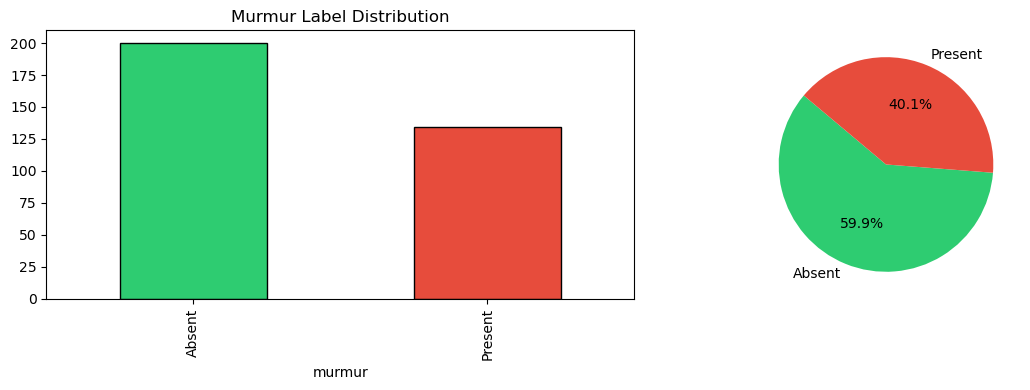

In [21]:
# Load and clean training data
df_train = pd.read_excel(CONFIG['TRAIN_CSV'])
df_train.columns = df_train.columns.str.strip()

# Identify ID and Murmur columns automatically
id_col = [c for c in df_train.columns if 'patient' in c.lower() and 'id' in c.lower()][0]
mur_col = [c for c in df_train.columns if 'murmur' in c.lower()][0]

df_train = df_train.rename(columns={id_col: 'patient_id', mur_col: 'murmur'})
df_train['patient_id'] = df_train['patient_id'].astype(str).str.strip()
df_train['label'] = (df_train['murmur'].str.strip().str.lower() == 'present').astype(int)

print(f"Total patients: {len(df_train)}")
print(df_train['murmur'].value_counts())

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_train['murmur'].value_counts().plot.bar(ax=axes[0], color=['#2ECC71', '#E74C3C'], edgecolor='black')
axes[0].set_title('Murmur Label Distribution')

df_train['murmur'].value_counts().plot.pie(ax=axes[1], autopct='%1.1f%%', colors=['#2ECC71', '#E74C3C'], startangle=140)
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

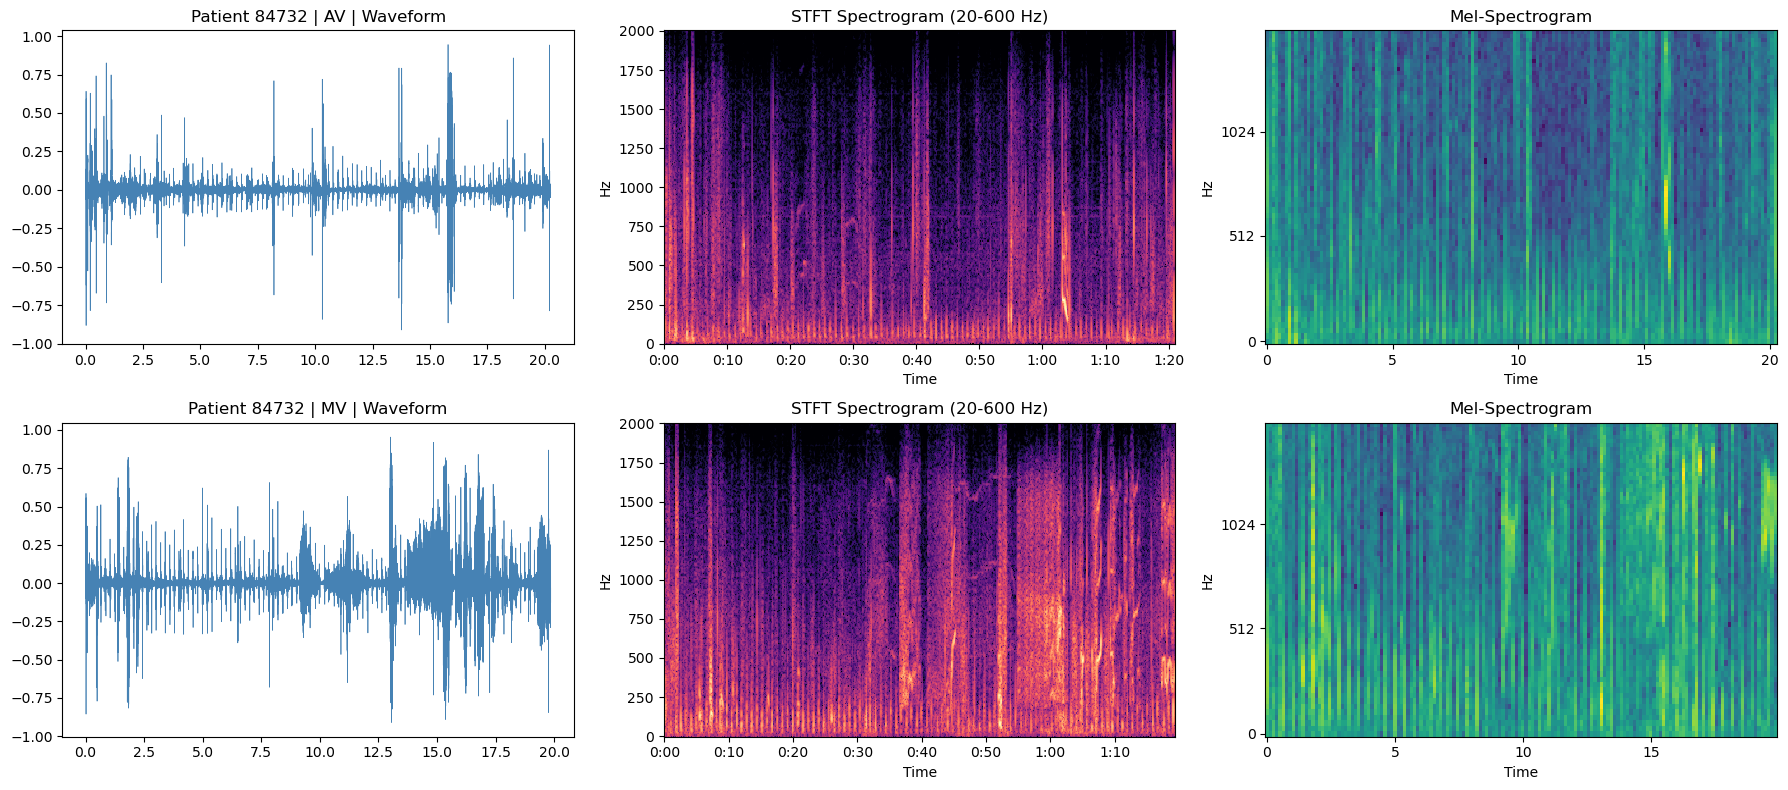

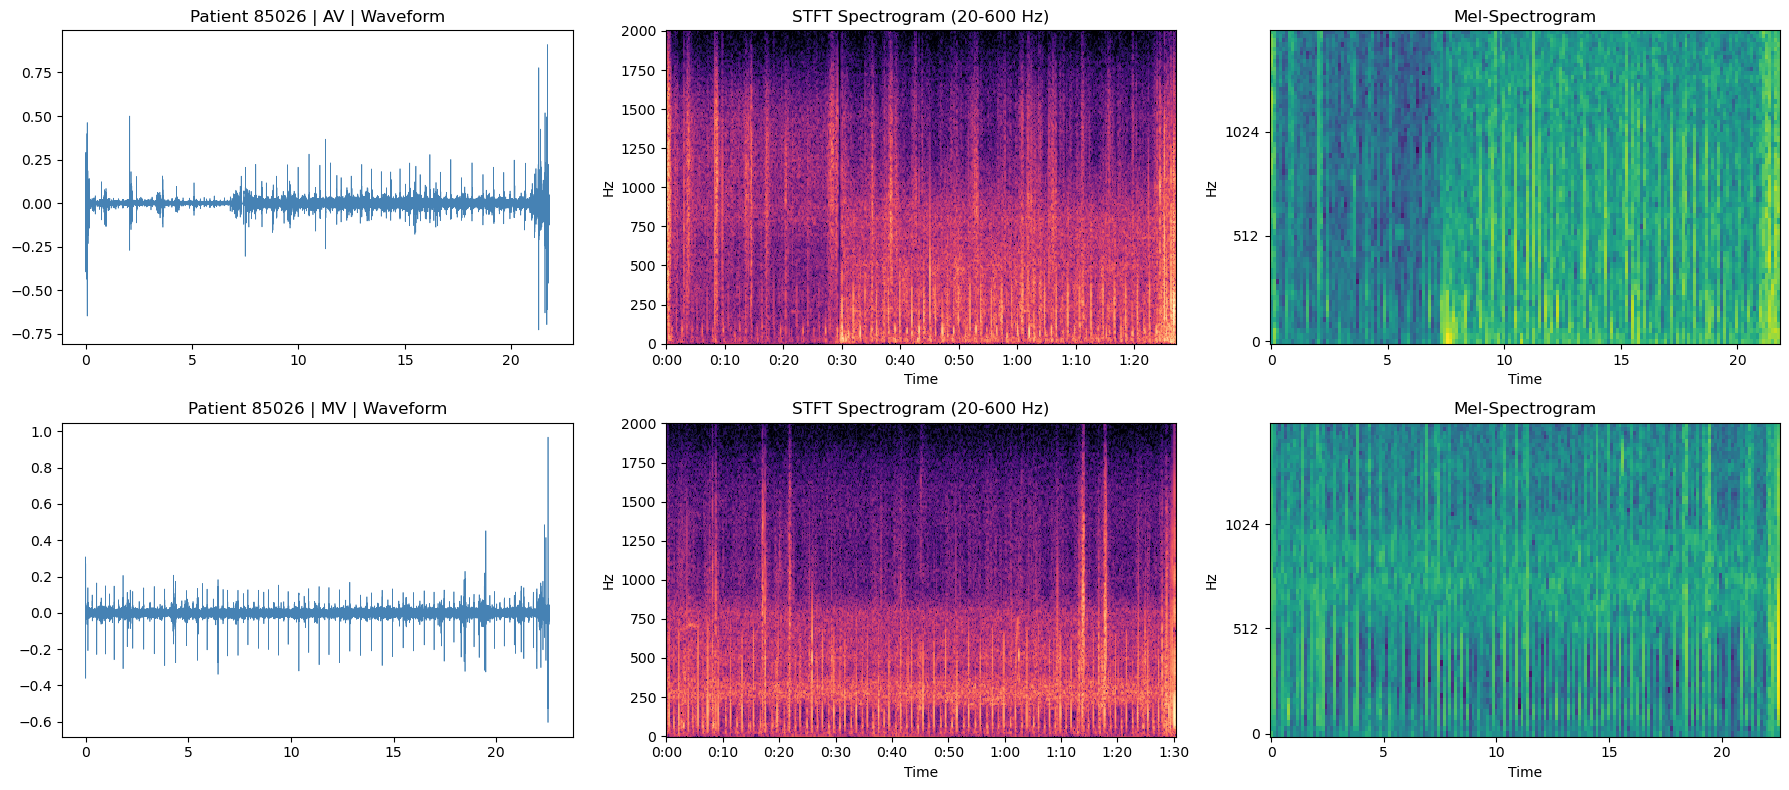

In [23]:
def find_wav_files(patient_id, data_root):
    pid = str(patient_id)
    patterns = [
        os.path.join(data_root, pid, f'{pid}*.wav'),
        os.path.join(data_root, f'{pid}*.wav'),
        os.path.join(data_root, pid, '*.wav'),
        os.path.join(data_root, '**', f'{pid}*.wav')
    ]
    found = []
    for p in patterns:
        found.extend(glob.glob(p, recursive=True))
    return sorted(list(set(found)))

def load_audio(filepath, target_sr):
    audio, sr = librosa.load(filepath, sr=target_sr, mono=True)
    return audio, sr

def visualise_patient_audio(patient_id, data_root, target_sr=4000):
    wavs = find_wav_files(patient_id, data_root)[:2] # Show first two recordings
    if not wavs:
        print(f"No audio found for patient {patient_id}")
        return
    
    fig, axes = plt.subplots(len(wavs), 3, figsize=(18, 4 * len(wavs)))
    if len(wavs) == 1: axes = axes[np.newaxis, :]
    
    for i, fp in enumerate(wavs):
        audio, sr = load_audio(fp, target_sr)
        valve = os.path.basename(fp).replace('.wav', '').split('_')[-1]
        t = np.linspace(0, len(audio)/sr, len(audio))
        
        # Waveform
        axes[i, 0].plot(t, audio, lw=0.5, color='steelblue')
        axes[i, 0].set_title(f'Patient {patient_id} | {valve} | Waveform')
        
        # STFT Spectrogram
        D = librosa.amplitude_to_db(np.abs(librosa.stft(audio, n_fft=512)), ref=np.max)
        librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[i, 1], fmin=20, fmax=600, cmap='magma')
        axes[i, 1].set_title('STFT Spectrogram (20-600 Hz)')
        
        # Mel-Spectrogram
        M = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=64, n_fft=512, fmin=20, fmax=600)
        librosa.display.specshow(librosa.power_to_db(M, ref=np.max), sr=sr, x_axis='time', y_axis='mel', ax=axes[i, 2], cmap='viridis')
        axes[i, 2].set_title('Mel-Spectrogram')
        
    plt.tight_layout()
    plt.show()

# Visualise example patients
try:
    present_pid = df_train[df_train['label'] == 1]['patient_id'].iloc[0]
    absent_pid = df_train[df_train['label'] == 0]['patient_id'].iloc[0]
    visualise_patient_audio(present_pid, CONFIG['DATA_ROOT'], CONFIG['TARGET_SR'])
    visualise_patient_audio(absent_pid, CONFIG['DATA_ROOT'], CONFIG['TARGET_SR'])
except:
    print("Could not find representative patients for visualization.")

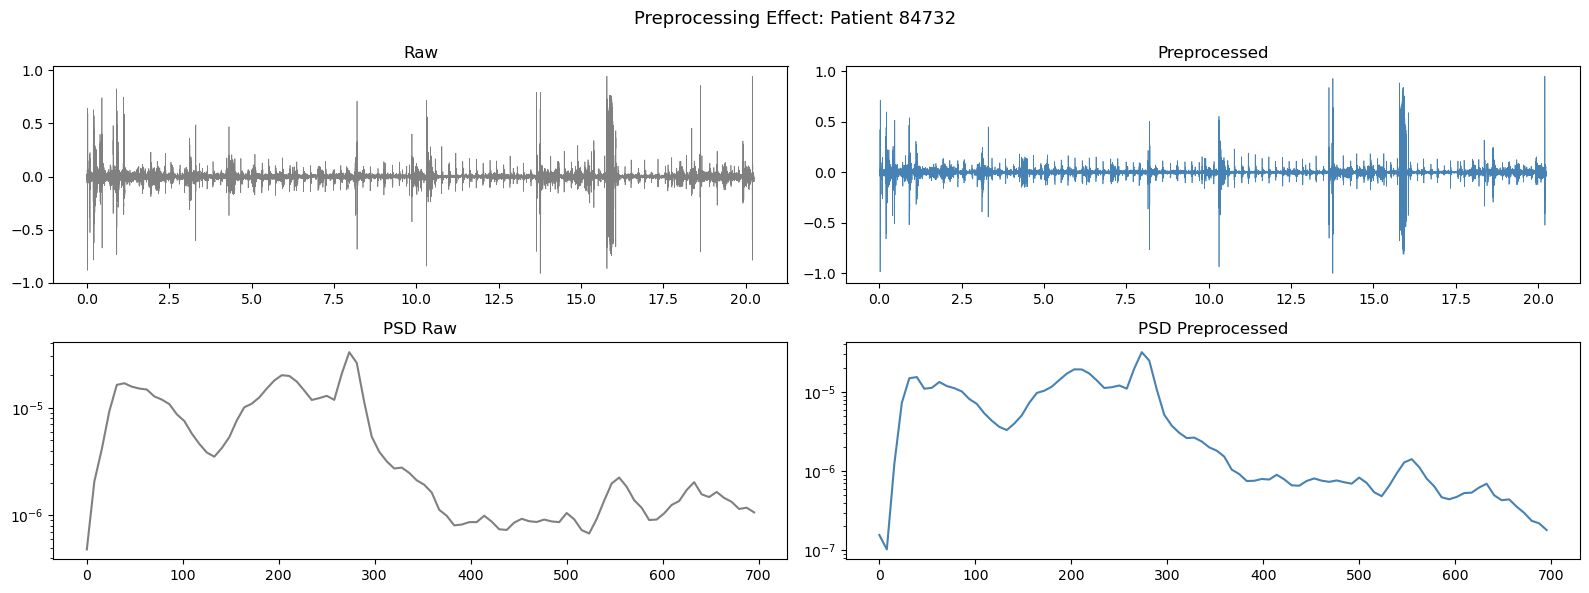

In [25]:
def bandpass_filter(audio, sr, low=20, high=600, order=4):
    nyq = sr / 2.0
    sos = butter(order, [low/nyq, high/nyq], btype='band', output='sos')
    return sosfilt(sos, audio)

def notch_filter(audio, sr, freq=50, Q=3.0):
    nyq = sr / 2.0
    b, a = iirnotch(freq / nyq, Q)
    return filtfilt(b, a, audio)

def wavelet_denoise(audio, wavelet='db6', level=5, threshold_mode='soft'):
    coeffs = pywt.wavedec(audio, wavelet, level=level)
    # Universal threshold calculation
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    thresh = sigma * np.sqrt(2 * np.log(len(audio)))
    
    denoised = [coeffs[0]]
    for c in coeffs[1:]:
        denoised.append(pywt.threshold(c, thresh, mode=threshold_mode))
    return pywt.waverec(denoised, wavelet)[:len(audio)]

def normalize_audio(audio):
    return audio / (np.max(np.abs(audio)) + 1e-8)

def preprocess_audio(audio, sr, cfg):
    audio = bandpass_filter(audio, sr, cfg['BANDPASS_LOW'], cfg['BANDPASS_HIGH'])
    audio = notch_filter(audio, sr, cfg['NOTCH_FREQ'], cfg['NOTCH_Q'])
    audio = wavelet_denoise(audio, cfg['WAVELET'], cfg['WAVELET_LEVEL'])
    audio = normalize_audio(audio)
    return audio

def compare_preprocessing(patient_id, data_root, cfg):
    wavs = find_wav_files(patient_id, data_root)
    if not wavs: return
    raw, sr = load_audio(wavs[0], cfg['TARGET_SR'])
    clean = preprocess_audio(raw.copy(), sr, cfg)
    t = np.linspace(0, len(raw)/sr, len(raw))
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 6))
    axes[0, 0].plot(t, raw, lw=0.5, color='gray')
    axes[0, 0].set_title('Raw')
    axes[0, 1].plot(t, clean, lw=0.5, color='steelblue')
    axes[0, 1].set_title('Preprocessed')
    
    fr, pr = signal.welch(raw, sr, nperseg=512)
    fc, pc = signal.welch(clean, sr, nperseg=512)
    mr, mc = fr <= 700, fc <= 700
    
    axes[1, 0].semilogy(fr[mr], pr[mr], color='gray')
    axes[1, 0].set_title('PSD Raw')
    axes[1, 1].semilogy(fc[mc], pc[mc], color='steelblue')
    axes[1, 1].set_title('PSD Preprocessed')
    
    plt.suptitle(f'Preprocessing Effect: Patient {patient_id}', fontsize=13)
    plt.tight_layout()
    plt.show()

compare_preprocessing(present_pid, CONFIG['DATA_ROOT'], CONFIG)

In [27]:
def audio_to_windows(audio, sr, window_samples, hop_samples):
    n = len(audio)
    if n < window_samples:
        audio = np.pad(audio, (0, window_samples - n))
        n = window_samples
    windows, start = [], 0
    while start + window_samples <= n:
        windows.append(audio[start:start+window_samples])
        start += hop_samples
    return windows

def window_to_melspec(window, sr, n_mels, n_fft, hop_length, f_min=20, f_max=600):
    M = librosa.feature.melspectrogram(
        y=window, sr=sr, n_mels=n_mels, n_fft=n_fft, 
        hop_length=hop_length, fmin=f_min, fmax=f_max, power=2.0
    )
    M_db = librosa.power_to_db(M, ref=np.max)
    # Normalize between 0 and 1
    M_db = (M_db - M_db.min()) / (M_db.max() - M_db.min() + 1e-8)
    return M_db.astype(np.float32)

def augment_window(window, sr):
    aug = window.copy()
    target = int(sr * CONFIG['WINDOW_SEC'])
    if np.random.rand() < 0.5:
        rate = np.random.uniform(0.9, 1.1)
        aug = librosa.effects.time_stretch(aug, rate=rate)
    if np.random.rand() < 0.3:
        n_steps = np.random.uniform(-2, 2)
        aug = librosa.effects.pitch_shift(aug, sr=sr, n_steps=n_steps)
    if np.random.rand() < 0.5:
        aug += np.random.randn(len(aug)) * 0.005
    
    # Force back to target length
    if len(aug) > target: 
        aug = aug[:target]
    else: 
        aug = np.pad(aug, (0, target - len(aug)))
    return aug

def build_dataset(df, cfg, augment=True, augment_factor=3):
    X, y, pids, missing = [], [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Building dataset'):
        pid, label = str(row['patient_id']), int(row['label'])
        wavs = find_wav_files(pid, cfg['DATA_ROOT'])
        if not wavs: 
            missing.append(pid)
            continue
            
        for fp in wavs:
            try:
                audio, sr = load_audio(fp, cfg['TARGET_SR'])
                audio = preprocess_audio(audio, sr, cfg)
                windows = audio_to_windows(audio, sr, cfg['WINDOW_SAMPLES'], cfg['HOP_SAMPLES'])
                
                for w in windows:
                    ms = window_to_melspec(w, sr, cfg['N_MELS'], cfg['N_FFT'], cfg['HOP_LENGTH'])
                    X.append(ms); y.append(label); pids.append(pid)
                    
                    if augment and label == 1:
                        for _ in range(augment_factor):
                            wa = augment_window(w, sr)
                            msa = window_to_melspec(wa, sr, cfg['N_MELS'], cfg['N_FFT'], cfg['HOP_LENGTH'])
                            X.append(msa); y.append(label); pids.append(pid)
            except Exception as e:
                print(f"Error on {fp}: {e}")
                
    if missing: print(f"{len(missing)} patients missing audio")
    X = np.array(X)[..., np.newaxis] # Add channel dimension
    return X, np.array(y), np.array(pids)

print("Building dataset (10-30 min)...")
X, y, patient_ids = build_dataset(df_train, CONFIG, augment=True, augment_factor=3)
print(f"Final Dataset Shape: {X.shape} | Label Balance: {np.bincount(y)}")

Building dataset (10-30 min)...


Building dataset: 100%|██████████| 334/334 [1:03:11<00:00, 11.35s/it]


Final Dataset Shape: (50901, 64, 94, 1) | Label Balance: [12333 38568]


In [29]:
# Split at patient level first
unique_pids = df_train['patient_id'].values
unique_labels = df_train['label'].values

train_pids, val_pids = train_test_split(
    unique_pids, test_size=0.20, random_state=SEED, stratify=unique_labels
)

train_mask = np.isin(patient_ids, train_pids)
val_mask = np.isin(patient_ids, val_pids)

X_tr, y_tr = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]

# Compute class weights for imbalanced training
cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weights = {i: cw[i] for i in range(len(cw))}

print(f"Train windows: {X_tr.shape} | Val windows: {X_val.shape}")
print(f"Class weights: {class_weights}")

Train windows: (39794, 64, 94, 1) | Val windows: (11107, 64, 94, 1)
Class weights: {0: 1.992489485279391, 1: 0.6675053676865271}


In [39]:
def build_cnn_bilstm(input_shape, num_classes=2, l2_reg=1e-4):
    reg = regularizers.l2(l2_reg)
    inp = keras.Input(shape=input_shape, name='mel_input')

    # Block 1
    x = layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=reg)(inp)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x); x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x); x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,1))(x); x = layers.Dropout(0.3)(x)

    # Squeeze-Excitation attention
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(64, activation='relu')(se)
    se = layers.Dense(128, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, 128))(se)
    x  = layers.Multiply()([x, se])

    # Reshape for RNN
    shape = x.shape
    x = layers.Reshape((shape[2], shape[1] * shape[3]))(x)

    # BiLSTM
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True,
                                          dropout=0.3, recurrent_dropout=0.2))(x)
    x = layers.Bidirectional(layers.LSTM(64,
                                          dropout=0.3, recurrent_dropout=0.2))(x)

    # Classifier head
    x   = layers.Dense(128, activation='relu', kernel_regularizer=reg)(x)
    x   = layers.Dropout(0.4)(x)
    x   = layers.Dense(64,  activation='relu', kernel_regularizer=reg)(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return keras.Model(inputs=inp, outputs=out, name='PCG_CNN_BiLSTM')


input_shape = X_tr.shape[1:]
model = build_cnn_bilstm(input_shape, num_classes=2)
model.summary()

opt = keras.optimizers.AdamW(learning_rate=CONFIG['LR'], weight_decay=1e-5)

# ── FIX: removed AUC from compile metrics to avoid the segment_ids shape
#         mismatch bug. ROC-AUC is still computed manually in Cell 11.
model.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled successfully')

Model: "PCG_CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mel_input           │ (None, 64, 94, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 94,    │        320 │ mel_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 94,    │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 64, 94,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 94,    │      9,248 │ activation_6[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 94,    │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 64, 94,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 47,    │          0 │ activation_7[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32, 47,    │          0 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 47,    │     18,496 │ dropout_5[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 47,    │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 32, 47,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 47,    │     36,928 │ activation_8[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 47,    │        256 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 32, 47,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 16, 23,    │          0 │ activation_9[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 16, 23,    │          0 │ max_pooling2d_4[

 Total params: 1,674,722 (6.39 MB)

 Trainable params: 1,673,826 (6.39 MB)

 Non-trainable params: 896 (3.50 KB)

Model compiled successfully


In [41]:
cb_list = [
    callbacks.ModelCheckpoint(
        CONFIG['MODEL_PATH'],
        monitor='val_accuracy',   # changed from val_auc
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_accuracy',   # changed from val_auc
        patience=CONFIG['PATIENCE'],
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=CONFIG['EPOCHS'],
    batch_size=CONFIG['BATCH_SIZE'],
    class_weight=class_weights,
    callbacks=cb_list,
    shuffle=True,
    verbose=1
)

print(f'Training complete. Best model saved to: {CONFIG["MODEL_PATH"]}')

Epoch 1/80
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.6921 - loss: 0.5588
Epoch 1: val_accuracy improved from None to 0.86567, saving model to murmur_model_best.h5



Epoch 1: finished saving model to murmur_model_best.h5
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 462s 338ms/step - accuracy: 0.7650 - loss: 0.4716 - val_accuracy: 0.8657 - val_loss: 0.3387 - learning_rate: 0.0010
Epoch 2/80
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.8347 - loss: 0.3782
Epoch 2: val_accuracy did not improve from 0.86567
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 458s 368ms/step - accuracy: 0.8412 - loss: 0.3652 - val_accuracy: 0.8083 - val_loss: 0.4449 - learning_rate: 0.0010
Epoch 3/80
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.8539 - loss: 0.3404
Epoch 3: val_accuracy did not improve from 0.86567
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 675s 507ms/step - accuracy: 0.8584 - loss: 0.3346 - val_accuracy: 0.8308 - val_loss: 0.4834 - learning_rate: 0.0010
Epoch 4/80
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.8653 - loss: 0.3265
Epoch 4: val_accuracy improved from 0.86567 to 0.87026, saving model to murmur_model_best.h5



Epoch 4: finished saving model to murmur_model_best.h5
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 657s 528ms/step - accuracy: 0.8700 - loss: 0.3192 - val_accuracy: 0.8703 - val_loss: 0.3311 - learning_rate: 0.0010
Epoch 5/80
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.8760 - loss: 0.3053
Epoch 5: val_accuracy did not improve from 0.87026
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 645s 518ms/step - accuracy: 0.8760 - loss: 0.3041 - val_accuracy: 0.8679 - val_loss: 0.3286 - learning_rate: 0.0010
Epoch 6/80
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.8804 - loss: 0.2968
Epoch 6: val_accuracy did not improve from 0.87026
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 515s 384ms/step - accuracy: 0.8839 - loss: 0.2924 - val_accuracy: 0.8531 - val_loss: 0.4314 - learning_rate: 0.0010
Epoch 7/80
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.8877 - loss: 0.2837
Epoch 7: val_accuracy did not improve from 0.87026
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 307s 247ms/step - accuracy: 0.8883 - loss: 0.2816


Epoch 11: finished saving model to murmur_model_best.h5
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 622s 499ms/step - accuracy: 0.9110 - loss: 0.2487 - val_accuracy: 0.8708 - val_loss: 0.4483 - learning_rate: 0.0010
Epoch 12/80
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.9139 - loss: 0.2435
Epoch 12: val_accuracy did not improve from 0.87080

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 419s 335ms/step - accuracy: 0.9148 - loss: 0.2421 - val_accuracy: 0.8443 - val_loss: 0.3907 - learning_rate: 0.0010
Epoch 13/80
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9308 - loss: 0.2103
Epoch 13: val_accuracy improved from 0.87080 to 0.88719, saving model to murmur_model_best.h5



Epoch 13: finished saving model to murmur_model_best.h5
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 312s 251ms/step - accuracy: 0.9344 - loss: 0.2025 - val_accuracy: 0.8872 - val_loss: 0.3724 - learning_rate: 5.0000e-04
Epoch 14/80
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.9389 - loss: 0.1908
Epoch 14: val_accuracy did not improve from 0.88719
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 316s 254ms/step - accuracy: 0.9393 - loss: 0.1905 - val_accuracy: 0.8728 - val_loss: 0.4094 - learning_rate: 5.0000e-04
Epoch 15/80
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.9428 - loss: 0.1831
Epoch 15: val_accuracy did not improve from 0.88719
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 304s 244ms/step - accuracy: 0.9442 - loss: 0.1813 - val_accuracy: 0.8746 - val_loss: 0.4494 - learning_rate: 5.0000e-04
Epoch 16/80
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.9479 - loss: 0.1747
Epoch 16: val_accuracy did not improve from 0.88719
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 352s 283ms/step - accuracy: 0.


Epoch 23: finished saving model to murmur_model_best.h5
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 315s 254ms/step - accuracy: 0.9766 - loss: 0.1116 - val_accuracy: 0.8930 - val_loss: 0.5329 - learning_rate: 2.5000e-04
Epoch 24/80
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.9770 - loss: 0.1099
Epoch 24: val_accuracy did not improve from 0.89304
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 317s 255ms/step - accuracy: 0.9774 - loss: 0.1084 - val_accuracy: 0.8657 - val_loss: 0.5960 - learning_rate: 2.5000e-04
Epoch 25/80
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.9795 - loss: 0.1047
Epoch 25: val_accuracy improved from 0.89304 to 0.89349, saving model to murmur_model_best.h5



Epoch 25: finished saving model to murmur_model_best.h5
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 317s 255ms/step - accuracy: 0.9795 - loss: 0.1019 - val_accuracy: 0.8935 - val_loss: 0.5022 - learning_rate: 2.5000e-04
Epoch 26/80
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.9810 - loss: 0.1032
Epoch 26: val_accuracy did not improve from 0.89349

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 500s 402ms/step - accuracy: 0.9815 - loss: 0.1008 - val_accuracy: 0.8879 - val_loss: 0.5303 - learning_rate: 2.5000e-04
Epoch 27/80
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.9846 - loss: 0.0924
Epoch 27: val_accuracy did not improve from 0.89349
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 632s 506ms/step - accuracy: 0.9859 - loss: 0.0890 - val_accuracy: 0.8864 - val_loss: 0.6332 - learning_rate: 1.2500e-04
Epoch 28/80
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.9861 - loss: 0.0868
Epoch 28: val_accuracy did not impr

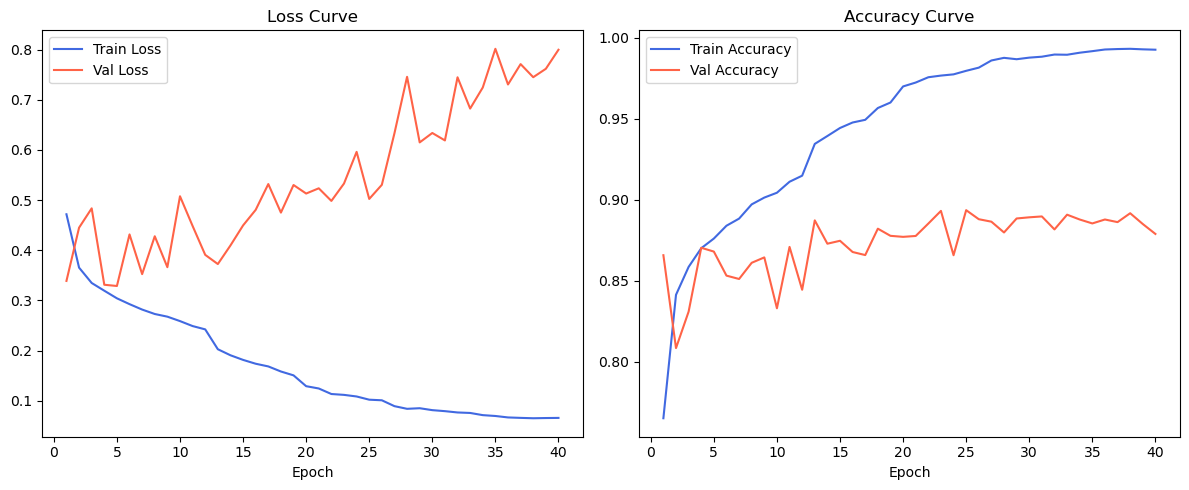

Window-Level Validation:
              precision    recall  f1-score   support

      Absent       0.71      0.85      0.77      2347
     Present       0.96      0.91      0.93      8760

    accuracy                           0.89     11107
   macro avg       0.83      0.88      0.85     11107
weighted avg       0.90      0.89      0.90     11107

ROC-AUC: 0.9537


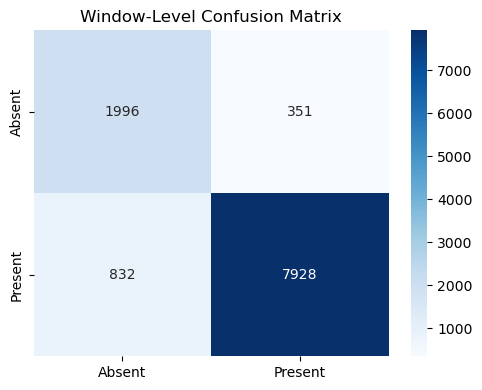

In [43]:
hist = history.history
ep   = range(1, len(hist['loss']) + 1)

# ── FIX: removed auc curve since AUC is no longer a training metric
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(ep, hist['loss'],          label='Train Loss',     color='royalblue')
axes[0].plot(ep, hist['val_loss'],      label='Val Loss',       color='tomato')
axes[0].set_title('Loss Curve'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(ep, hist['accuracy'],      label='Train Accuracy', color='royalblue')
axes[1].plot(ep, hist['val_accuracy'],  label='Val Accuracy',   color='tomato')
axes[1].set_title('Accuracy Curve'); axes[1].legend(); axes[1].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150); plt.show()

# Load best checkpoint and evaluate at window level
best_model = keras.models.load_model(CONFIG['MODEL_PATH'])

y_pred_proba = best_model.predict(X_val, batch_size=64, verbose=0)
y_pred_class = np.argmax(y_pred_proba, axis=1)

print('Window-Level Validation:')
print(classification_report(y_val, y_pred_class,
                             target_names=['Absent', 'Present']))
print(f'ROC-AUC: {roc_auc_score(y_val, y_pred_proba[:, 1]):.4f}')

cm = confusion_matrix(y_val, y_pred_class)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Absent', 'Present'],
            yticklabels=['Absent', 'Present'])
plt.title('Window-Level Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_windows.png', dpi=150); plt.show()

In [45]:
def predict_patient(patient_id, model, cfg, verbose=False):
    pid = str(patient_id)
    wavs = find_wav_files(pid, cfg['DATA_ROOT'])
    if not wavs: return 0.5, 'Absent', 0
    
    all_probs = []
    for fp in wavs:
        try:
            audio, sr = load_audio(fp, cfg['TARGET_SR'])
            audio = preprocess_audio(audio, sr, cfg)
            windows = audio_to_windows(audio, sr, cfg['WINDOW_SAMPLES'], cfg['HOP_SAMPLES'])
            specs = np.array([window_to_melspec(w, sr, cfg['N_MELS'], cfg['N_FFT'], cfg['HOP_LENGTH']) for w in windows])[..., np.newaxis]
            
            preds = model.predict(specs, batch_size=32, verbose=0)
            all_probs.extend(preds[:, 1].tolist())
        except Exception as e:
            if verbose: print(f"Error on {fp}: {e}")
            
    if not all_probs: return 0.5, 'Absent', 0
    pa = np.array(all_probs)
    
    # Weighted ensemble: 40% mean, 35% P75, 25% max
    prob_final = (0.40 * np.mean(pa)) + (0.35 * np.percentile(pa, 75)) + (0.25 * np.max(pa))
    decision = 'Present' if prob_final > cfg['PATIENT_THRESHOLD'] else 'Absent'
    return prob_final, decision, len(all_probs)

# Cell 13: Validate Patients
val_results = []
for pid in tqdm(val_pids, desc='Validating patients'):
    true_label = df_train[df_train['patient_id'] == str(pid)]['label'].values[0]
    prob, decision, n_win = predict_patient(pid, best_model, CONFIG)
    val_results.append({
        'patient_id': pid,
        'true_label': 'Present' if true_label == 1 else 'Absent',
        'predicted': decision,
        'probability': round(prob, 4),
        'correct': decision == ('Present' if true_label == 1 else 'Absent')
    })

df_vr = pd.DataFrame(val_results)
print(f"Patient-Level Accuracy: {df_vr['correct'].mean()*100:.2f}%")

Validating patients: 100%|██████████| 67/67 [00:39<00:00,  1.71it/s]

Patient-Level Accuracy: 80.60%


Running patient-level validation...


Validating patients: 100%|██████████| 67/67 [01:41<00:00,  1.52s/it]


Patient-Level Accuracy: 86.57%
patient_id true_label predicted  probability  correct
     84977     Absent    Absent       0.3284     True
     85114     Absent    Absent       0.3115     True
     47002    Present   Present       0.9470     True
     50099    Present   Present       1.0000     True
     84996     Absent    Absent       0.4788     True
     85115     Absent    Absent       0.0506     True
     50260    Present   Present       0.7990     True
     85285     Absent   Present       0.6811    False
     85264     Absent   Present       0.7528    False
     50136    Present   Present       1.0000     True
     49712    Present   Present       0.9979     True
     85252     Absent    Absent       0.2805     True
     49751    Present   Present       0.9775     True
     85122     Absent    Absent       0.3469     True
     85337     Absent    Absent       0.2685     True
     85167     Absent    Absent       0.3202     True
     68708    Present   Present       1.0000     Tr

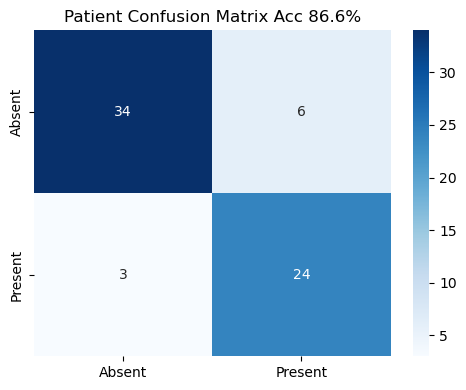

In [53]:
print('Running patient-level validation...')
val_results = []
for pid in tqdm(val_pids, desc='Validating patients'):
    true_label = df_train[df_train['patient_id'] == str(pid)]['label'].values[0]
    prob, decision, n_win = predict_patient(pid, best_model, CONFIG)
    val_results.append({
        'patient_id': pid,
        'true_label': 'Present' if true_label == 1 else 'Absent',
        'predicted': decision,
        'probability': round(prob, 4),
        'correct': decision == ('Present' if true_label == 1 else 'Absent')
    })

df_vr = pd.DataFrame(val_results)
acc = df_vr['correct'].mean()
print(f'Patient-Level Accuracy: {acc*100:.2f}%')
print(df_vr.to_string(index=False))

y_tp = (df_vr['true_label'] == 'Present').astype(int)
y_pp = (df_vr['predicted'] == 'Present').astype(int)
print(classification_report(y_tp, y_pp, target_names=['Absent', 'Present']))

cm = confusion_matrix(y_tp, y_pp)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Absent', 'Present'], yticklabels=['Absent', 'Present'])
plt.title(f'Patient Confusion Matrix Acc {acc*100:.1f}%')
plt.tight_layout(); plt.savefig('confusion_patients.png', dpi=150); plt.show()

In [55]:
thresholds = np.arange(0.20, 0.70, 0.02)
accs = []
true_binary = (df_vr['true_label'] == 'Present').astype(int)

for t in thresholds:
    preds_binary = (df_vr['probability'] >= t).astype(int)
    accs.append(accuracy_score(true_binary, preds_binary))

best_threshold = thresholds[np.argmax(accs)]
CONFIG['PATIENT_THRESHOLD'] = float(best_threshold)
print(f"Optimal threshold: {best_threshold:.2f} | Best Acc: {max(accs)*100:.2f}%")

Optimal threshold: 0.68 | Best Acc: 86.57%


In [67]:
# ================================================================
# PASTE YOUR 50 TEST PATIENT IDs BELOW
# ================================================================
TEST_PATIENT_IDS = [
    '50009', '50012', '50014', '50015', '50017', '50018', '50023', '50026', '50027', '50029',
    '50032', '50034', '50037', '50043', '50047', '50048', '50049', '50053', '50057', '50061',
    '50066', '50067', '50070', '50072', '50074', '50075', '50076', '50077', '50078', '50079',
    '50080', '50085', '50086', '50089', '50092', '50094', '50096', '50100', '50103', '50104',
    '50105', '50109', '50111', '50113', '50117', '50119', '50121', '50122', '50125', '50126',
    '68487', '68560', '68567', '68582', '68708', '68740', '68874', '69068', '69079', '69093',
    '69096', '69120', '69147', '69155', '72283', '73497', '76240', '77373', '78280', '83094',
    '84690', '84692', '84693', '84695', '84702', '84714', '84718', '84730', '84732', '84751',
    '84786', '84802', '84834', '84840', '84853', '84854', '84857', '84863', '84864', '84865',
    '84882', '84885', '84896', '84937', '84949',
    '84937',
    '84949',
    '85002',
    '85004',
    '85024',
    '85030',
    '85031',
    '85036',
    '85037',
    '85042',
    '85055',
    '85057',
    '85069',
    '85079',
    '85080',
    '85087',
    '85108',
    '85110',
    '49562',
    '49568',
    '49577',
    '49585',
    '49598',
    '49610',
    '49622',
    '49631',
    '49641',
    '85110',
    '85119',
    '85132',
    '85133',
    '85135',
    '85145',
    '85165',
    '85169' 
]
# ================================================================

best_model = keras.models.load_model(CONFIG['MODEL_PATH'])
test_results = []
for pid in tqdm(TEST_PATIENT_IDS, desc='Predicting'):
    prob, decision, n_win = predict_patient(pid, best_model, CONFIG, verbose=False)
    test_results.append({
        'patient_id': pid,
        'murmur': decision,
        'confidence': f'{prob*100:.1f}%',
        'n_windows': n_win
    })

df_test = pd.DataFrame(test_results)
print('=' * 50); print(' FINAL MURMUR DETECTION RESULTS'); print('=' * 50)
for _, row in df_test.iterrows():
    print(f"Patient ID: {str(row['patient_id']).ljust(15)} | "
          f"Murmur: {row['murmur'].ljust(7)} | "
          f"Confidence: {row['confidence']}")
print('=' * 50)
print(f"Total Present : {(df_test['murmur']=='Present').sum()}")
print(f"Total Absent : {(df_test['murmur']=='Absent').sum()}")
df_test[['patient_id','murmur']].to_csv('test_predictions.csv', index=False)
print('Predictions saved to test_predictions.csv')

Predicting: 100%|██████████| 130/130 [03:35<00:00,  1.66s/it]

 FINAL MURMUR DETECTION RESULTS
Patient ID: 50009           | Murmur: Absent  | Confidence: 8.0%
Patient ID: 50012           | Murmur: Present | Confidence: 98.6%
Patient ID: 50014           | Murmur: Absent  | Confidence: 31.7%
Patient ID: 50015           | Murmur: Absent  | Confidence: 26.0%
Patient ID: 50017           | Murmur: Absent  | Confidence: 59.0%
Patient ID: 50018           | Murmur: Absent  | Confidence: 32.2%
Patient ID: 50023           | Murmur: Absent  | Confidence: 39.0%
Patient ID: 50026           | Murmur: Absent  | Confidence: 51.8%
Patient ID: 50027           | Murmur: Absent  | Confidence: 50.3%
Patient ID: 50029           | Murmur: Absent  | Confidence: 27.0%
Patient ID: 50032           | Murmur: Absent  | Confidence: 28.4%
Patient ID: 50034           | Murmur: Absent  | Confidence: 33.5%
Patient ID: 50037           | Murmur: Present | Confidence: 81.1%
Patient ID: 50043           | Murmur: Present | Confidence: 80.7%
Patient ID: 50047           | Murmur: Absent 

Final Test Accuracy: 87.69%
              precision    recall  f1-score   support

      Absent       0.86      0.86      0.86        59
     Present       0.89      0.89      0.89        71

    accuracy                           0.88       130
   macro avg       0.88      0.88      0.88       130
weighted avg       0.88      0.88      0.88       130



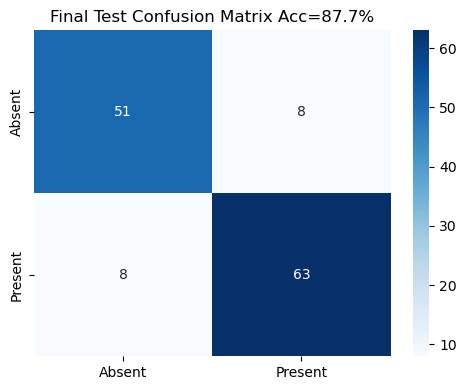

In [69]:
# Fill in true labels after you receive them
GROUND_TRUTH = {
    '50009': 'Absent',
    '50012': 'Absent',
    '50014': 'Absent',
    '50015': 'Absent',
    '50017': 'Absent',
    '50018': 'Absent',
    '50023': 'Absent',
    '50026': 'Absent',
    '50027': 'Absent',
    '50029': 'Absent',
    '50032': 'Absent',
    '50034': 'Absent',
    '50037': 'Absent',
    '50043': 'Absent',
    '50047': 'Absent',
    '50048': 'Absent',
    '50049': 'Absent',
    '50053': 'Absent',
    '50057': 'Absent',
    '50061': 'Absent',
    '50066': 'Absent',
    '50067': 'Absent',
    '50070': 'Absent',
    '50072': 'Absent',
    '50074': 'Absent',
    '50075': 'Absent',
    '50076': 'Absent',
    '50077': 'Absent',
    '50078': 'Absent',
    '50079': 'Absent',
    '50080': 'Absent',
    '50085': 'Absent',
    '50086': 'Absent',
    '50089': 'Absent',
    '50092': 'Absent',
    '50094': 'Absent',
    '50096': 'Absent',
    '50100': 'Absent',
    '50103': 'Absent',
    '50104': 'Absent',
    '50105': 'Absent',
    '50109': 'Absent',
    '50111': 'Absent',
    '50113': 'Absent',
    '50117': 'Absent',
    '50119': 'Absent',
    '50121': 'Absent',
    '50122': 'Absent',
    '50125': 'Absent',
    '50126': 'Absent',
    '23625': 'Absent',
    '24160': 'Absent',
    '31737': 'Absent',
    '38337': 'Absent',
    '39043': 'Absent',
    '39403': 'Absent',
    '84937': 'Present',
    '84949': 'Present',
    '85002': 'Present',
    '85004': 'Present',
    '85024': 'Present',
    '85030': 'Present',
    '85031': 'Present',
    '85036': 'Present',
    '85037': 'Present',
    '85042': 'Present',
    '85055': 'Present',
    '85057': 'Present',
    '85069': 'Present',
    '85079': 'Present',
    '85080': 'Present',
    '85087': 'Present',
    '85108': 'Present',
    '85110': 'Present',
    '40058': 'Absent',
    '40798': 'Absent',
    '43852': 'Absent',
    '46532': 'Absent',
    '49561': 'Absent',
    '49562': 'Absent',
    '49568': 'Absent',
    '49577': 'Absent',
    '49585': 'Absent',
    '49598': 'Absent',
    '49610': 'Absent',
    '49622': 'Absent',
    '49631': 'Absent',
    '49641': 'Absent',
    '85110': 'Present',
    '85119': 'Present',
    '85132': 'Present',
    '85133': 'Present',
    '85135': 'Present',
    '85145': 'Present',
    '85165': 'Present',
    '85169': 'Present',
    '85172': 'Present',
    '85198': 'Present',
    '85199': 'Present',
    '85207': 'Present',
    '85219': 'Present',
    '85243': 'Present',
    '85259': 'Present',
    '85261': 'Present',
    '85269': 'Present',
    '85276': 'Present',
    '85306': 'Present',
    '85339': 'Present',
    '85343': 'Present',
    '68487': 'Present',
    '68560': 'Present',
    '68567': 'Present',
    '68582': 'Present',
    '68708': 'Present',
    '68740': 'Present',
    '68874': 'Present',
    '69068': 'Present',
    '69079': 'Present',
    '69093': 'Present',
    '69096': 'Present',
    '69120': 'Present',
    '69147': 'Present',
    '69155': 'Present',
    '72283': 'Present',
    '73497': 'Present',
    '76240': 'Present',
    '77373': 'Present',
    '78280': 'Present',
    '83094': 'Present',
    '84690': 'Present',
    '84692': 'Present',
    '84693': 'Present',
    '84695': 'Present',
    '84702': 'Present',
    '84714': 'Present',
    '84718': 'Present',
    '84730': 'Present',
    '84732': 'Present',
    '84751': 'Present',
    '84786': 'Present',
    '84802': 'Present',
    '84834': 'Present',
    '84840': 'Present',
    '84853': 'Present',
    '84854': 'Present',
    '84857': 'Present',
    '84863': 'Present',
    '84864': 'Present',
    '84865': 'Present',
    '84882': 'Present',
    '84885': 'Present',
    '84896': 'Present',
    '84937': 'Present',
    '84949': 'Present'
}

if GROUND_TRUTH:
    df_test['true_label'] = df_test['patient_id'].astype(str).map(GROUND_TRUTH)
    df_eval = df_test.dropna(subset=['true_label'])
    acc = accuracy_score(df_eval['true_label'], df_eval['murmur'])
    print(f'Final Test Accuracy: {acc*100:.2f}%')
    print(classification_report(df_eval['true_label'], df_eval['murmur'], target_names=['Absent', 'Present']))
    cm = confusion_matrix(df_eval['true_label'], df_eval['murmur'], labels=['Absent', 'Present'])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Absent', 'Present'], yticklabels=['Absent', 'Present'])
    plt.title(f'Final Test Confusion Matrix Acc={acc*100:.1f}%')
    plt.tight_layout(); plt.savefig('final_test_confusion.png', dpi=150); plt.show()
else:
    print('Fill in GROUND_TRUTH dict to measure accuracy.')